<a href="https://colab.research.google.com/github/amal750/project/blob/main/452.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2025-11-30 215016.png to Screenshot 2025-11-30 215016 (8).png


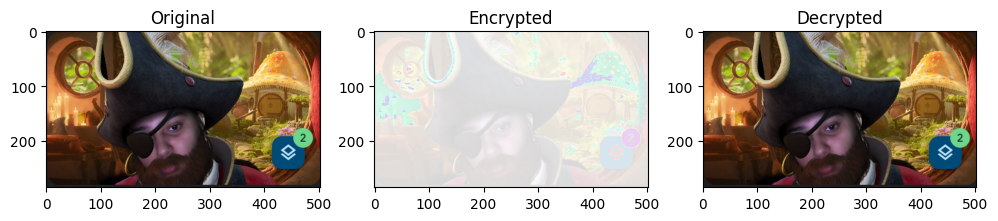

In [10]:
# ceaser cipher
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

image = Image.open(next(iter(uploaded)))
img = np.array(image)

key = 50

encrypted = (img.astype(int) + key) % 256
decrypted = (encrypted - key) % 256

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(encrypted.astype(np.uint8)); plt.title("Encrypted")
plt.subplot(1,3,3); plt.imshow(decrypted.astype(np.uint8)); plt.title("Decrypted")
plt.show()

Saving Screenshot 2025-11-30 215016.png to Screenshot 2025-11-30 215016 (9).png


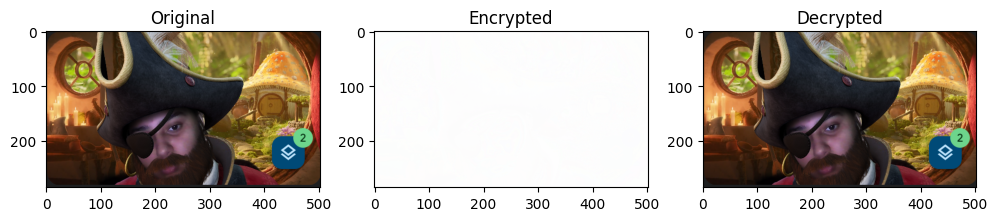

In [11]:
#affine cipher
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

image = Image.open(next(iter(uploaded)))
img = np.array(image)

a = 5
b = 8

a_inv = pow(a, -1, 256)

encrypted = (a * img.astype(int) + b) % 256
decrypted = (a_inv * (encrypted - b)) % 256

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(encrypted.astype(np.uint8)); plt.title("Encrypted")
plt.subplot(1,3,3); plt.imshow(decrypted.astype(np.uint8)); plt.title("Decrypted")
plt.show()

Saving Screenshot 2025-11-30 215016.png to Screenshot 2025-11-30 215016 (10).png


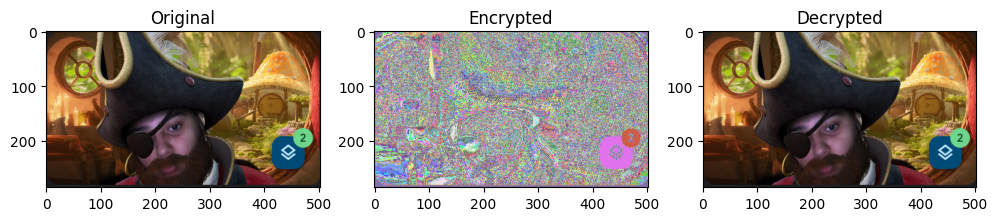

In [12]:
# s-box cipher
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

image = Image.open(next(iter(uploaded)))
img = np.array(image)

sbox = np.arange(256)
np.random.shuffle(sbox)
inv_sbox = np.argsort(sbox)

encrypted = sbox[img.astype(int)]
decrypted = inv_sbox[encrypted]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(encrypted.astype(np.uint8)); plt.title("Encrypted")
plt.subplot(1,3,3); plt.imshow(decrypted.astype(np.uint8)); plt.title("Decrypted")
plt.show()

Saving Screenshot 2025-11-30 215016.png to Screenshot 2025-11-30 215016 (12).png


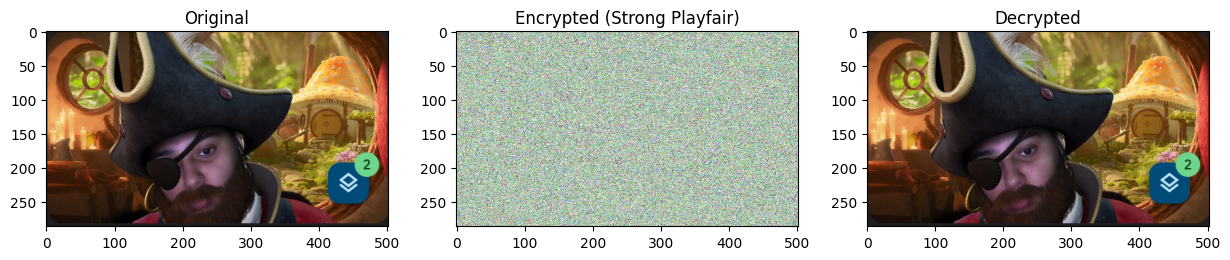

In [14]:
#playfair cipher
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

image = Image.open(next(iter(uploaded)))
img = np.array(image)

# flatten + important cast
flat = img.flatten().astype(int)

# fix randomness (important for consistency)
np.random.seed(42)

# STEP 1: permutation (very important for strong encryption)
perm = np.random.permutation(len(flat))
inv_perm = np.argsort(perm)

# STEP 2: apply permutation
shuffled = flat[perm]

# STEP 3: Playfair-like pair operation (stronger values)
encrypted = shuffled.copy()

for i in range(0, len(shuffled)-1, 2):
    encrypted[i]   = (shuffled[i] + 70) % 256
    encrypted[i+1] = (shuffled[i+1] + 130) % 256

# STEP 4: decryption (reverse operations)
decrypted = encrypted.copy()

for i in range(0, len(encrypted)-1, 2):
    decrypted[i]   = (encrypted[i] - 70) % 256
    decrypted[i+1] = (encrypted[i+1] - 130) % 256

# undo permutation
decrypted = decrypted[inv_perm]

# reshape back
encrypted_img = encrypted.reshape(img.shape)
decrypted_img = decrypted.reshape(img.shape)

# display
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(encrypted_img.astype(np.uint8))
plt.title("Encrypted (Strong Playfair)")

plt.subplot(1,3,3)
plt.imshow(decrypted_img.astype(np.uint8))
plt.title("Decrypted")

plt.show()